In [5]:
import pandas as pd
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
data =df.drop(['Time'], axis=1)
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

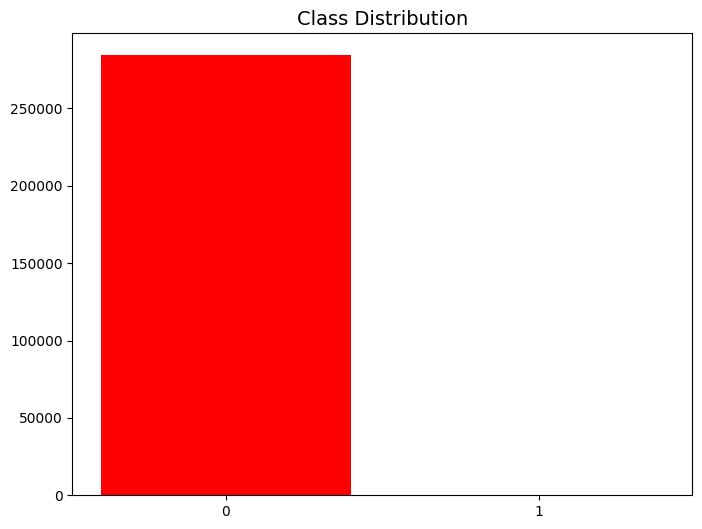

In [8]:
rcParams['figure.figsize'] = 8, 6
plt.bar(data['Class'].unique(), data['Class'].value_counts(), color=['red', 'green'])
plt.xticks([0, 1])
plt.title("Class Distribution", fontsize=14)
plt.show()

In [9]:
x = data.drop('Class',axis=1)
y = data['Class']

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
Hp_param = {'criterion':['gini','entropy'],'max_depth':[1,2,3,4,5,10,15,20]}
tree_GS_param = GridSearchCV(DecisionTreeClassifier(),Hp_param,cv=5,scoring='roc_auc',n_jobs=-1,verbose=1)
tree_GS_param.fit(x_train,y_train)
print("The best parameter combined is .................")
print(tree_GS_param.best_params_)
print("the best score is.......")
print(tree_GS_param.best_score_)



Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best parameter combined is .................
{'criterion': 'entropy', 'max_depth': 4}
the best score is.......
0.9395910170270605


In [12]:
y_pred = tree_GS_param.predict(x_test)

In [14]:
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))
 
#Calculate sensitivity and specificity
 
total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)
 
sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )
 
specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

[[56850    14]
 [   18    80]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.85      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9994382219725431
Sensitivity :  0.9997537985368599
Specificity :  0.8163265306122449


In [24]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
pip install pydotplus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24660 sha256=12fa209bdab75ecfd685dcd8a91f91f3ffcfac79866bd45ab10557588b40a086
  Stored in directory: c:\users\test\appdata\local\pip\cache\wheels\77\54\7c\c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
pip install Ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from sklearn.tree import export_graphviz
from sklearn import tree 
import graphviz
import pydotplus
from IPython.display import Image

In [30]:
from sklearn.tree import export_graphviz
import graphviz
 
best_model = tree_GS_param.best_estimator_
 
dot_data = export_graphviz(
    best_model,
    out_file=None,
    feature_names=x_train.columns,
    class_names=["Good", "Fraud"],
    filled=True,
    rounded=True
)
 
graph = graphviz.Source(dot_data)
graph

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [40]:
from sklearn.ensemble import BaggingClassifier
hp_bagging = {'n_estimators':[3,4,5,6]}
Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(tree_bagg.best_params_)  #gets best estimator
Final_Model=tree_bagg.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(tree_bagg.best_score_)  #gets best score for best estimator # -0.83828599184062269


Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'n_estimators': 6}
The best AUC score was 
0.9173319629974422


In [41]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
Hyper_paramters_RF={'criterion':['gini','entropy'],'max_depth':[4,10],'n_estimators':[50, 100], 'max_features':['sqrt'] }



Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(tree_bagg.best_params_)  #gets best estimator
Final_Model=tree_bagg.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(tree_bagg.best_score_)  #gets best score for best estimator # -0.83828599184062269


Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'n_estimators': 6}
The best AUC score was 
0.919866939553606
